## 不同阈值边缘提取效果对比

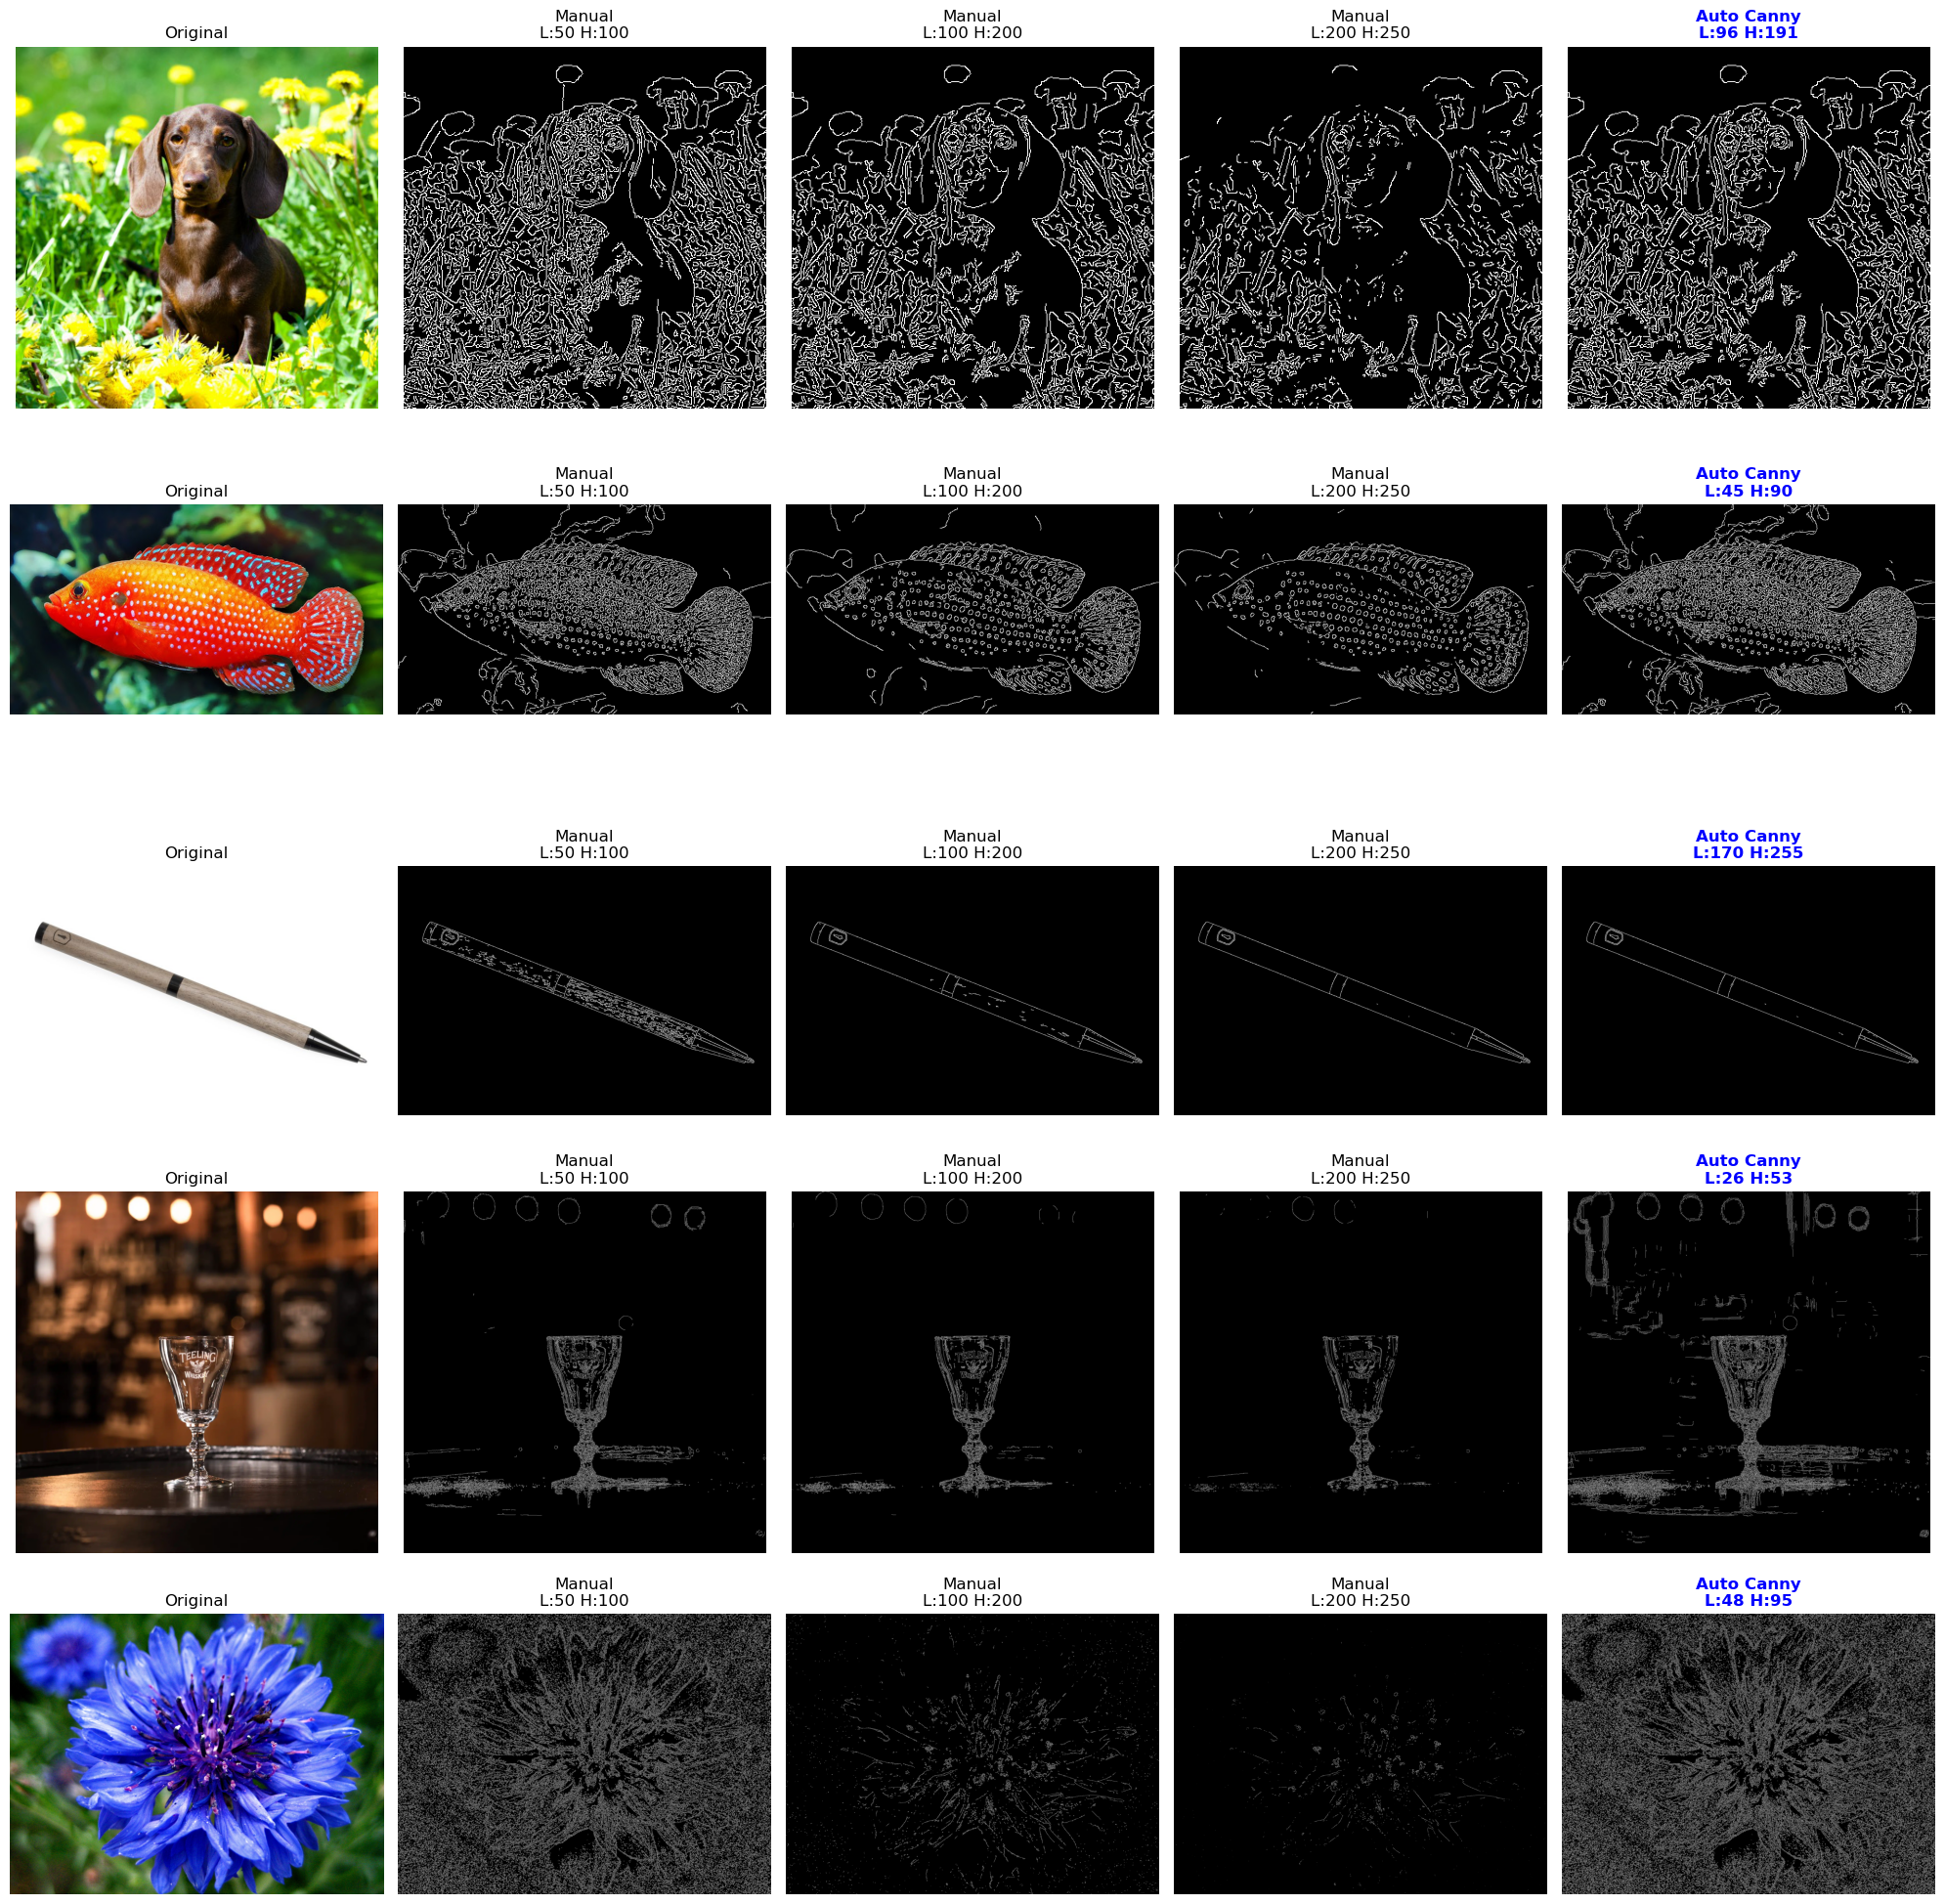

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def auto_canny(image, sigma=0.33):
    """根据图像中位数自动计算 Canny 阈值"""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper


def visualize_canny_effects(image_paths, threshold_list=[(50, 100), (100, 200), (200, 250)]):
    """
    对图片展示不同 Canny 阈值效果对比
        (50, 100),   较低阈值：边缘非常丰富，但噪声也多
        (100, 200),  中等阈值：平衡点
        (200, 250),  较高阈值：只保留最显著的边缘
        (50, 250)    跨度极大：利用滞后阈值连接长边缘
    """
    num_images = len(image_paths)
    # 列数：原图 + 手动阈值数量 + 自动阈值结果
    num_cols = 1 + len(threshold_list) + 1
    
    fig, axes = plt.subplots(num_images, num_cols, figsize=(4 * num_cols, 4 * num_images))
    
    if num_images == 1:
        axes = [axes]

    for row, img_path in enumerate(image_paths):
        img = cv2.imread(img_path)
        if img is None: continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # 原图
        axes[row][0].imshow(img_rgb)
        axes[row][0].set_title("Original")
        axes[row][0].axis('off')
        
        # 手动阈值对比
        for i, (low, high) in enumerate(threshold_list):
            edges = cv2.Canny(gray, low, high)
            axes[row][i + 1].imshow(edges, cmap='gray')
            axes[row][i + 1].set_title(f"Manual\nL:{low} H:{high}")
            axes[row][i + 1].axis('off')
        
        # 自动阈值对比 (Auto Canny)
        auto_low, auto_high = auto_canny(gray)
        auto_edges = cv2.Canny(gray, auto_low, auto_high)
        axes[row][-1].imshow(auto_edges, cmap='gray')
        axes[row][-1].set_title(f"Auto Canny\nL:{auto_low} H:{auto_high}", color='blue', fontweight='bold')
        axes[row][-1].axis('off')

    plt.tight_layout()
    plt.show()

paths = [r"C:\Users\jytna\OneDrive - TUM\MM\dackel.jpg",r"C:\Users\jytna\OneDrive - TUM\MM\fish.jpg", r"C:\Users\jytna\OneDrive - TUM\MM\pen.jpg",
        r"C:\Users\jytna\OneDrive - TUM\MM\glass.jpg", r"C:\Users\jytna\OneDrive - TUM\MM\flower.jpg"]
visualize_canny_effects(paths)